# File for generating figures in the manuscript

This Notebook refers to the manuscript `impact_analysis.tex`

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import cellpylib as cpl
import igraph as ig
import h5py

from matplotlib import rcParams

from tqdm import tqdm

# Configure matplotlib backend for stability
import matplotlib

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,  # Disable LaTeX for now - try without it first
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # Use DejaVu Serif instead
    "figure.dpi": 100,
    "savefig.dpi": 300,
})

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

from src.analysis import hamming_weight, boolean_sens, mean_field_dens_propagation, derrida_map_analytical
from src.rules import return_life_like_dict, return_equivalent_rule, binary_indices
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.visual import get_ugent_colors_dict

life_like_dict = return_life_like_dict()

%load_ext autoreload
%autoreload 2

# Introduction

- Background and rationale of the work
- Existing approaches
- Our research question

# Definitions

- Definition of the small world network
- Definition of the LLNA
- Definition of HW and BS

# Methods

### Structural ranking

In [4]:
# various networks have different distributions of centrality measures on their nodes

# Create a small-world network using the Watts-Strogatz model

# Parameters
width = 50                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast. 200 takes 10 minutes
num_nodes = width**2
rewiring_prob = 0.2         # Rewiring probability
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)

small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

Network: 2500 nodes, 10000 edges
Plot created successfully


51

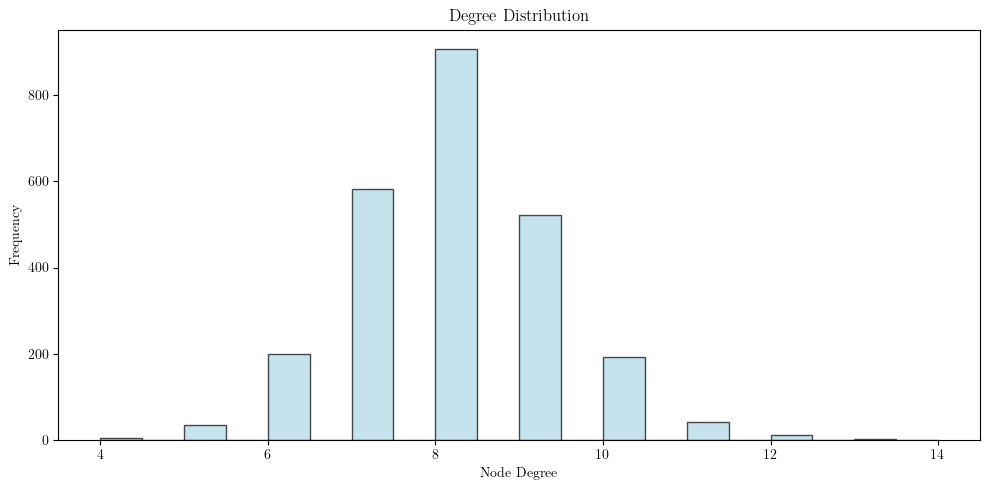

In [5]:
# Instead of computing centrality (which crashes), let's compute simpler metrics
import gc
gc.collect()

# Get basic network properties
print(f"Network: {small_world_graph.vcount()} nodes, {small_world_graph.ecount()} edges")

# Compute degree distribution instead (much faster and safer)
degrees = small_world_graph.degree()

# Create a simple plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(degrees, bins=20, color='lightblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Node Degree')
ax.set_ylabel('Frequency')
ax.set_title('Degree Distribution')
plt.tight_layout()

print("Plot created successfully")
gc.collect()

### Node pinning